# Business Analytics para Showz 🎫

## 1. Revisión inicial y preparación de los datos

### 1.1. Cargar librerías y archivos

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [43]:
orders = pd.read_csv('datasets/orders_log_us.csv')
visits = pd.read_csv('datasets/visits_log_us.csv')
costs = pd.read_csv('datasets/costs_us.csv')

### 1.2. DataFrame Orders

In [44]:
# Revisión inicial del DataFrame 'orders'
orders.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [45]:
print(orders.info())
print()
print(orders.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None

            Revenue           Uid
count  50415.000000  5.041500e+04
mean       4.999647  9.098161e+18
std       21.818359  5.285742e+18
min        0.000000  3.135781e+14
25%        1.220000  4.533567e+18
50%        2.500000  9.102274e+18
75%        4.890000  1.368290e+19
max     2633.280000  1.844617e+19


In [46]:
# Modificar los nombres de las columnas para facilitar su uso

orders_col_names = []

for col in orders.columns:
    col = col.lower().strip().replace(' ', '_')
    orders_col_names.append(col)

orders.columns = orders_col_names
orders.columns

Index(['buy_ts', 'revenue', 'uid'], dtype='object')

In [47]:
# Convertir columna 'Buy Ts' a tipo datetime
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


### 1.3. DataFrame Visits

In [48]:
# Revisión inicial del DataFrame 'visits'
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [49]:
print(visits.info())
print()
print(visits.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None

         Device               End Ts      Source Id             Start Ts  \
count    359400               359400  359400.000000               359400   
unique        2               224760            NaN               224303   
top     desktop  2017-11-24 16:51:00            NaN  2017-11-24 16:06:00   
freq     262567                   23            NaN                   19   
mean        NaN                  NaN       3.750515                  NaN   
std         NaN                  NaN       1.917116                  NaN   
min       

In [50]:
# Modificar los nombres de las columnas para facilitar su uso

visits_col_names = []

for col in visits.columns:
    col = col.lower().strip().replace(' ', '_')
    visits_col_names.append(col)

visits.columns = visits_col_names
visits.columns

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')

In [51]:
# Convertir las columnas 'End Ts' y 'Start Ts' a tipo datetime
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])

visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


### 1.4. DataFrame Costs

In [52]:
# Revisión inicial del DataFrame 'Costs'
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [53]:
costs.info()
costs.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


In [54]:
# Convertir la columna 'dt' a tipo datetime
costs['dt'] = pd.to_datetime(costs['dt'])

costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


### <b>Observaciones

-	Se importaron las librerías de `pandas`, para leer los archivos y trabajar con DataFrames, `numpy` para trabajos específicos con los datos del tipo datetime, `seaborn` para la generacion de mapas de calor y `pyplot` para generar graficos.
-	Fue necesario modificar el nombre de las columnas de los DataFrames `orders` y `visits` para que tuvieran un formato mas fácil de manejar. Ademas fue necesario cambiar las columnas con fechas de los 3 DataFrames para convertirlos al tipo de dato ‘datetime’ para poder trabajar con facilidad en el análisis posterior.

## 2. Hacer informes y calcular métricas

### 2.1. Visitas

In [55]:
# 1. Cuántas personas lo usan cada día, semana, mes
# Crear columnas de día de la sesión, semana y mes
visits['day'] = visits['start_ts'].dt.to_period('D')
visits['week'] = visits['start_ts'].dt.to_period('W').dt.start_time
visits['month'] = visits['start_ts'].dt.to_period('M')

# Calcular usuarios únicos por día, semana y mes
dau = visits.groupby('day')['uid'].nunique()
wau = visits.groupby('week')['uid'].nunique()
mau = visits.groupby('month')['uid'].nunique()

# Imprimir los usuarios promedios por día, semana y mes
print(f'Usuarios activos diarios (DAU) promedio: {int(dau.mean().round())}')
print(f'Usuarios activos semanales (WAU) promedio: {int(wau.mean().round())}')
print(f'Usuarios activos mensuales (MAU) promedio: {int(mau.mean().round())}')

Usuarios activos diarios (DAU) promedio: 908
Usuarios activos semanales (WAU) promedio: 5716
Usuarios activos mensuales (MAU) promedio: 23228


In [56]:
# 2. ¿Cuántas sesiones hay por día?
# Agrupar por día y contar sesiones
sessions_per_day = visits.groupby('day').agg({'uid': 'count'})

print('Por día hay un promedio de', int(sessions_per_day['uid'].mean()), 'sesiones.')

Por día hay un promedio de 987 sesiones.


In [57]:
# 3. ¿Cuál es la duración de cada sesión?
# Crear una nueva columna para la duración de la sesión en minutos
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']) / np.timedelta64(1, 'm')

# filtrar los valores de duración de sesión negativos o en ceros
valid_sessions = visits[visits['session_duration'] > 0]
print('La duración promedio de una sesión es de', valid_sessions['session_duration'].mean().round(2), 'minutos.')

La duración promedio de una sesión es de 11.9 minutos.


In [58]:
# 4. ¿Con qué frecuencia los usuarios regresan?
visits.head()
# Calcular la frecuencia de visitas por usuario
frequency = visits.groupby('uid').agg({'day': 'nunique'})
print(frequency.describe())
print()
# Crear un slice para analizar los usuarios con mas de una visita
frequent_users = frequency[frequency['day'] > 1]
print(frequent_users.describe())

                 day
count  228169.000000
mean        1.448527
std         2.610167
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       259.000000

               day
count  45045.00000
mean       3.27195
std        5.51071
min        2.00000
25%        2.00000
50%        2.00000
75%        3.00000
max      259.00000


In [59]:
# Promedio de visitas por usuario
print('El usuario promedio visita el sitio', frequency['day'].mean().round(2), 'veces.')

# Promedio de visitas por usuario frecuente (Se calculará la mediana para evitar sesgos por outliers)
print('El usuario frecuente visita el sitio', frequent_users['day'].median().round(2), 'veces.')

El usuario promedio visita el sitio 1.45 veces.
El usuario frecuente visita el sitio 2.0 veces.


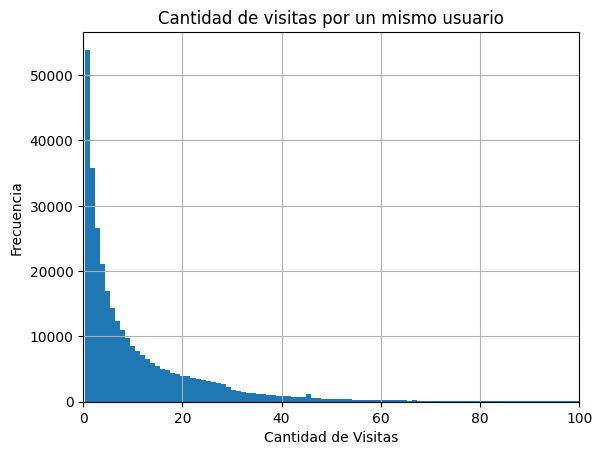

In [60]:
# Graficar las visitas 

valid_sessions['session_duration'].hist(bins=700)
plt.title('Cantidad de visitas por un mismo usuario')
plt.xlim(0,100)
plt.xlabel('Cantidad de Visitas')
plt.ylabel('Frecuencia')

plt.show()

<b> CONCLUSIONES INTERMEDIAS

-	La página tiene actividad diaria de 908 usuarios. Es decir, las métricas de la compañía se ven afectadas diariamente por la interacción de los usuarios.
-	Las visitas de los usuarios duran en promedio 11.9 minutos.
-	La gran mayoría de los usuarios (aprox. 80%) solo han ingresado un día. El otro 20% restante en su mayoría visita el sitio 2 días.

### 2.2. Ventas

In [61]:
# 1. ¿Cuándo empieza la gente a comprar?
# Hacer lista con los IDs únicos de los compradores
buyers_id = orders['uid'].unique().tolist()

# Filtrar el DataFrame de visitas para obtener solo los compradores
buyers_visits = visits[visits['uid'].isin(buyers_id)].reset_index(drop=True)
buyers_visits_ = buyers_visits[['uid', 'device', 'source_id', 'day']]

# Crear columna day en orders
orders['day'] = orders['buy_ts'].dt.to_period('D')

# Encontrar la primera compra de los clientes
user_first_purchase = orders.groupby('uid').agg({'day': 'min'}).reset_index()
user_first_purchase.columns = ['uid', 'first_purchase']

# Encontrar la primer visita de los clientes
users_first_visit = visits.groupby('uid').min()['day'].reset_index()
users_first_visit.columns = ['uid', 'first_visit']

In [62]:
# Unir los dataframes user_first_visit y user_first purchase a buyers_visits_
buyers_visits_ = buyers_visits_.merge(users_first_visit, on='uid', how='left')
buyers_visits_ = buyers_visits_.merge(user_first_purchase, on='uid', how='left')

buyers_visits_

,uid,device,source_id,day,first_visit,first_purchase
0,16174680259334210214,desktop,9,2018-05-20,2018-03-09,2018-03-09
1,16007536194108375387,desktop,5,2017-09-03,2017-09-03,2017-09-04
2,8056418121947262981,desktop,4,2018-02-06,2017-06-04,2017-06-25
3,18188358787673499603,touch,2,2018-02-12,2018-02-10,2018-02-12
4,2307401184189569202,desktop,4,2017-12-05,2017-09-23,2017-09-27
...,...,...,...,...,...,...
97389,18363291481961487539,desktop,2,2017-07-29,2017-07-29,2017-07-29
97390,18370831553019119586,touch,1,2018-01-25,2018-01-25,2018-01-25
97391,18387297585500748294,desktop,4,2018-03-03,2018-03-03,2018-03-03
97392,18388616944624776485,desktop,5,2017-11-02,2017-11-02,2017-11-02


In [63]:
# Crear columna indicando los días que tardaron los clientes en hacer su primera compra
buyers_visits_['days_to_conversion'] = ((buyers_visits_['first_purchase'] - buyers_visits_['first_visit']) / np.timedelta64(1, 'D')).astype('int64')
buyers_visits_['days_to_conversion']

0         0
1         1
2        21
3         2
4         4
         ..
97389     0
97390     0
97391     0
97392     0
97393     0
Name: days_to_conversion, Length: 97394, dtype: int64

In [64]:
# Agregar una columna que los clasifique en grupos segun los días de conversion
# Revisar el rango de los días de conversion
buyers_visits_['days_to_conversion'].describe()

count    97394.000000
mean        33.713750
std         63.348208
min          0.000000
25%          0.000000
50%          1.000000
75%         37.000000
max        363.000000
Name: days_to_conversion, dtype: float64

In [65]:
# Bucle para clasificar los días de conversión

conversion_cohorts = []

for days in buyers_visits_['days_to_conversion']:
    if days == 0:
        conversion_cohorts.append('group 1')
    elif 1 <= days <= 2:
        conversion_cohorts.append('group 2')
    elif 3 <= days <= 5:
        conversion_cohorts.append('group 3')
    elif 6 <= days <= 10:
        conversion_cohorts.append('group 4')
    elif 10 <= days <= 20:
        conversion_cohorts.append('group 5')
    elif 21 <= days <= 35:
        conversion_cohorts.append('group 6')
    elif days >= 36:
        conversion_cohorts.append('group 7')

In [66]:
# Agregar columna 'groups' al dataframe
buyers_visits_['groups'] = pd.Series(conversion_cohorts)
buyers_visits_.head()

,uid,device,source_id,day,first_visit,first_purchase,days_to_conversion,groups
0,16174680259334210214,desktop,9,2018-05-20,2018-03-09,2018-03-09,0,group 1
1,16007536194108375387,desktop,5,2017-09-03,2017-09-03,2017-09-04,1,group 2
2,8056418121947262981,desktop,4,2018-02-06,2017-06-04,2017-06-25,21,group 6
3,18188358787673499603,touch,2,2018-02-12,2018-02-10,2018-02-12,2,group 2
4,2307401184189569202,desktop,4,2017-12-05,2017-09-23,2017-09-27,4,group 3


In [67]:
# Verificar que todo salio bien
print(buyers_visits_[buyers_visits_['groups'] == 'group 1']['days_to_conversion'].describe())
print(buyers_visits_[buyers_visits_['groups'] == 'group 2']['days_to_conversion'].describe())
print(buyers_visits_[buyers_visits_['groups'] == 'group 6']['days_to_conversion'].describe())

count    44417.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: days_to_conversion, dtype: float64
count    8870.000000
mean        1.279143
std         0.448603
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: days_to_conversion, dtype: float64
count    5406.000000
mean       26.586201
std         4.451555
min        21.000000
25%        22.000000
50%        27.000000
75%        30.000000
max        35.000000
Name: days_to_conversion, dtype: float64


In [68]:
# Hacer un dataframe donde solo aparezca información de la visita de la primer compra del cliente
first_purchases = buyers_visits_[buyers_visits_['day'] == buyers_visits_['first_purchase']]

# Filtrar el DataFrame para que no haya User ID duplicados y ahora si obtener solo la primer compra de cada Usuario
first_purchases_ = first_purchases[~first_purchases['uid'].duplicated()]
first_purchases_.head()

,uid,device,source_id,day,first_visit,first_purchase,days_to_conversion,groups
3,18188358787673499603,touch,2,2018-02-12,2018-02-10,2018-02-12,2,group 2
6,15857957287537270437,desktop,3,2018-03-12,2017-09-22,2018-03-12,171,group 7
8,15868686231870595097,touch,5,2018-03-27,2018-03-27,2018-03-27,0,group 1
16,9344114199116964256,desktop,5,2018-02-25,2018-02-25,2018-02-25,0,group 1
19,14063997464143962003,desktop,4,2018-01-25,2017-11-25,2018-01-25,61,group 7


In [69]:
# Se agrupa el dataframe de 'first_purchases_' en la columa'groups' y 'source_id' para comparar que fuente de adquisición capta que grupos.
sales_report = first_purchases_.groupby(['groups', 'source_id']).agg({'uid':'count'})
sales_report.head()

uid
groups  source_id      
group 1 1          2523
        2          2283
        3          6769
        4          6763
        5          5318

In [70]:
sales_report_pivot = sales_report.pivot_table(
    index= 'groups',
    columns= 'source_id',
    values= 'uid',
    aggfunc= 'mean'
)

sales_report_pivot

source_id,1,2,3,4,5,7,9,10
groups,,,,,,,,
group 1,2523.0,2283.0,6769.0,6763.0,5318.0,1.0,432.0,950.0
group 2,443.0,265.0,237.0,315.0,221.0,NaN,24.0,53.0
group 3,128.0,140.0,100.0,180.0,100.0,NaN,10.0,15.0
group 4,114.0,111.0,80.0,151.0,97.0,NaN,19.0,18.0
group 5,108.0,125.0,78.0,150.0,100.0,NaN,22.0,14.0
group 6,105.0,99.0,97.0,144.0,90.0,NaN,31.0,15.0
group 7,421.0,473.0,508.0,721.0,420.0,NaN,124.0,67.0


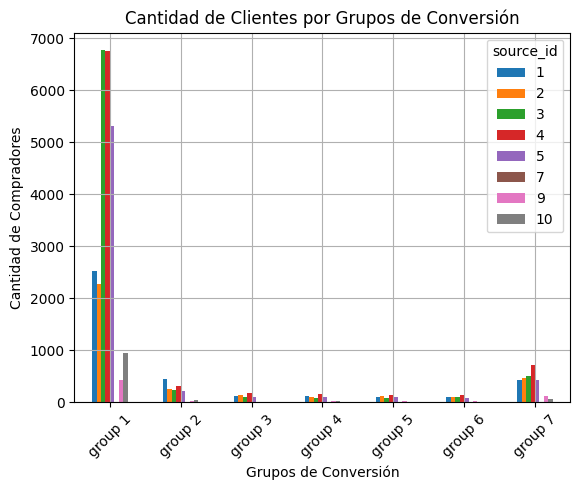

In [71]:
sales_report_pivot.plot(kind='bar')
plt.grid()
plt.title('Cantidad de Clientes por Grupos de Conversión')
plt.xlabel('Grupos de Conversión')
plt.ylabel('Cantidad de Compradores')
plt.xticks(rotation= 45)

plt.show()

In [72]:
# 2. ¿Cuántos pedidos hacen durante un período de tiempo dado?
# Se agregará la columna 'week' y 'month' al dataframe orders para analizarlo por grupos de tiempo
orders['week'] = orders['buy_ts'].dt.to_period('W').dt.start_time
orders['month'] = orders['buy_ts'].dt.to_period('M').dt.start_time

# Agrupar compras por semana y mes
weekly_purchases = orders.groupby('week').agg({'buy_ts':'count', 'revenue':'sum'})
monthly_purchases = orders.groupby('month').agg({'buy_ts':'count', 'revenue':'sum'})

In [73]:
print('La cantidad promedio de compras semanales fue:', weekly_purchases['buy_ts'].mean().round())
print('La cantidad promedio de compras mensuales fue:', monthly_purchases['buy_ts'].mean().round()) 

La cantidad promedio de compras semanales fue: 951.0
La cantidad promedio de compras mensuales fue: 3878.0


In [74]:
# 3. ¿Cuál es el tamaño promedio de compra?
weekly_mean_revenue = weekly_purchases['revenue'].mean().round(2)
monthly_mean_revenue = monthly_purchases['revenue'].mean().round(2)

print('La compra semanal promedio es:', weekly_mean_revenue)
print('La compra mensual promedio es:', monthly_mean_revenue)

La compra semanal promedio es: 4755.8
La compra mensual promedio es: 19389.02


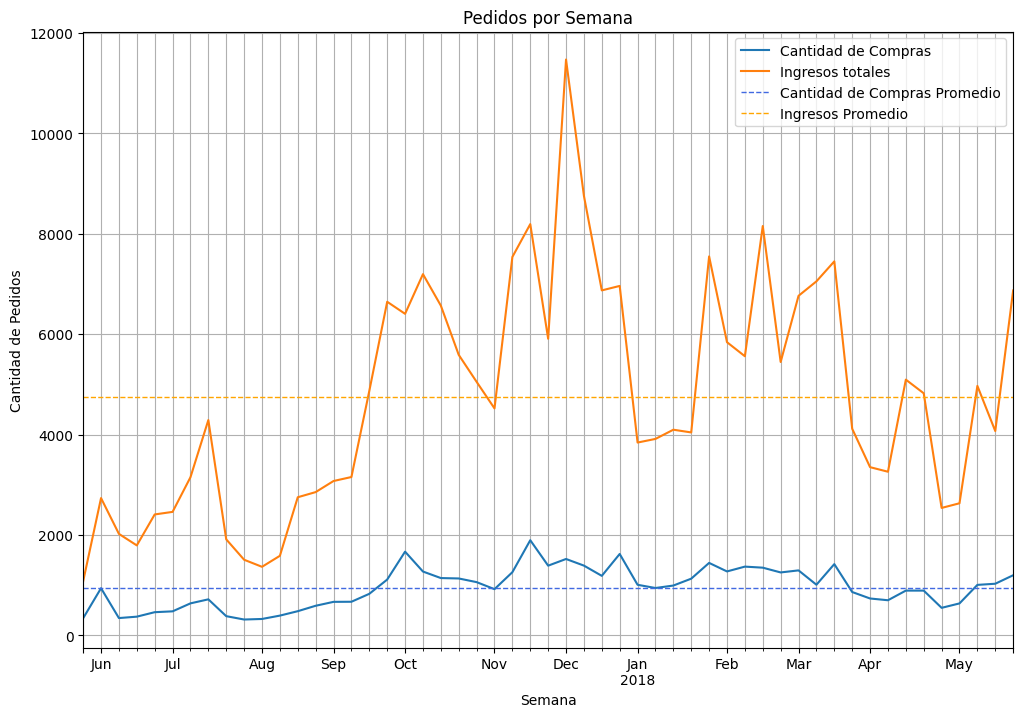

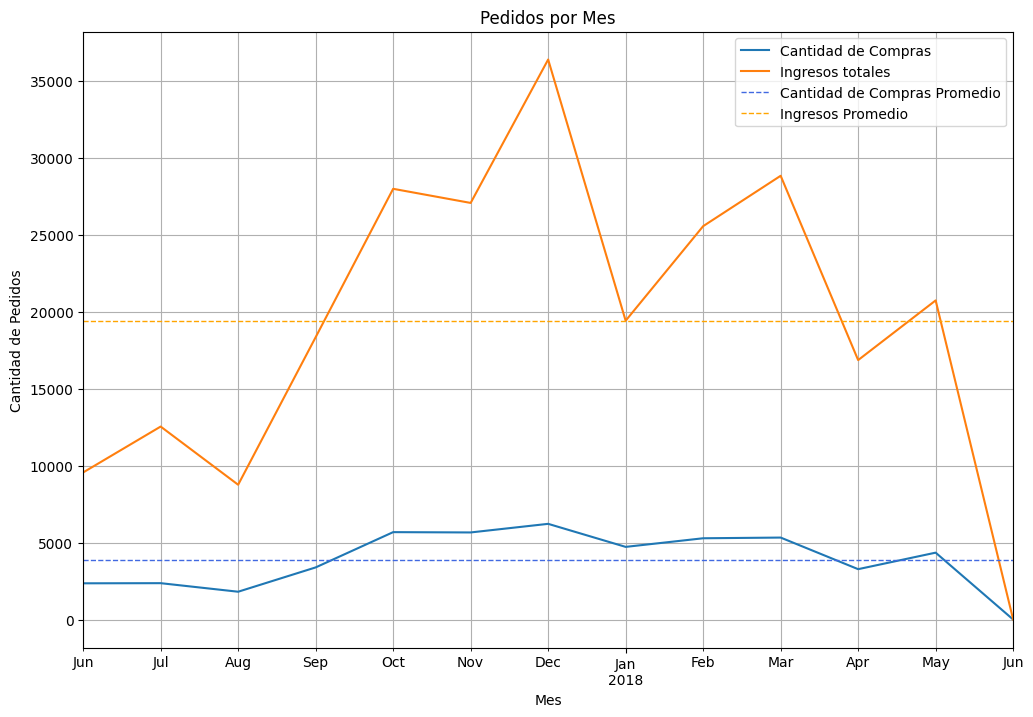

In [75]:
# Graficar los resultados del punto 2 y 3
# a) Grafica semanal ----------------------------------------
weekly_purchases.plot(figsize= [12,8])
plt.axhline(
    y= weekly_purchases['buy_ts'].mean(),
    color='royalblue',
    linestyle='--',
    linewidth=1
)
plt.axhline(
    y= weekly_purchases['revenue'].mean(),
    color='orange',
    linestyle='--',
    linewidth=1
)
plt.legend(['Cantidad de Compras', 'Ingresos totales', 'Cantidad de Compras Promedio', 'Ingresos Promedio'])
plt.grid(which='both')
plt.title('Pedidos por Semana')
plt.xlabel('Semana')
plt.ylabel('Cantidad de Pedidos')

# b) Grafica mensual ----------------------------------------
monthly_purchases.plot(figsize= [12,8])
plt.axhline(
    y= monthly_purchases['buy_ts'].mean(),
    color='royalblue',
    linestyle='--',
    linewidth=1
)
plt.axhline(
    y= monthly_purchases['revenue'].mean(),
    color='orange',
    linestyle='--',
    linewidth=1
)
plt.legend(['Cantidad de Compras', 'Ingresos totales', 'Cantidad de Compras Promedio', 'Ingresos Promedio'])
plt.grid(which='both')
plt.title('Pedidos por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pedidos')

plt.show()

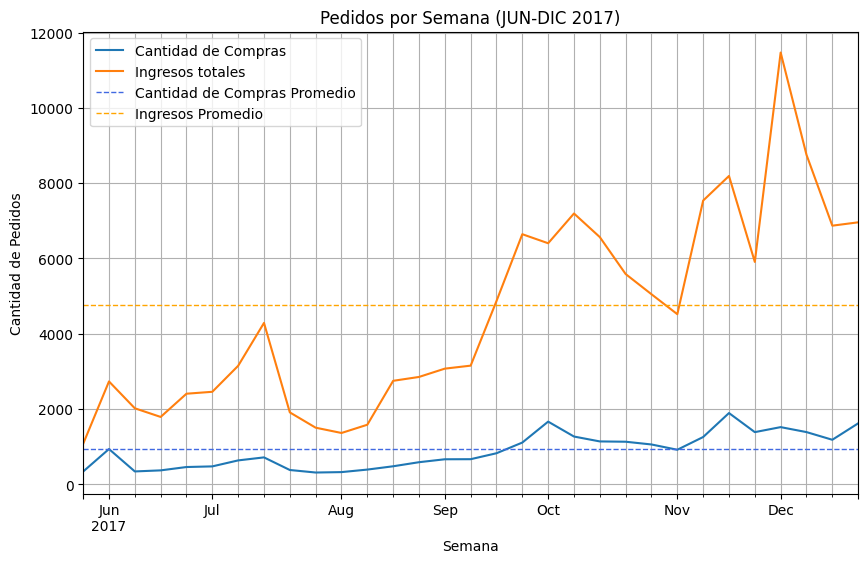

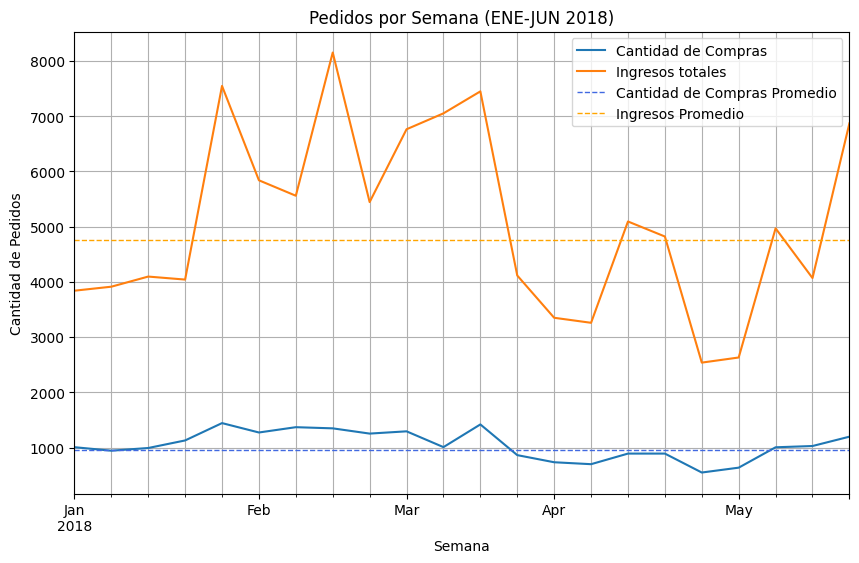

In [76]:
# Analizar más de cerca 'weekly_purchases'
# Análisis de Junio a Diciembre ----------------------------------------
weekly_purchases[:31].plot(figsize=[10,6])
plt.axhline(
    y= weekly_purchases['buy_ts'].mean(),
    color='royalblue',
    linestyle='--',
    linewidth=1
)
plt.axhline(
    y= weekly_purchases['revenue'].mean(),
    color='orange',
    linestyle='--',
    linewidth=1
)
plt.legend(['Cantidad de Compras', 'Ingresos totales', 'Cantidad de Compras Promedio', 'Ingresos Promedio'])
plt.grid(which='both')
plt.title('Pedidos por Semana (JUN-DIC 2017)')
plt.xlabel('Semana')
plt.ylabel('Cantidad de Pedidos')

# Análisis de Enero a Junio ----------------------------------------
weekly_purchases[31:].plot(figsize= [10,6])
plt.axhline(
    y= weekly_purchases['buy_ts'].mean(),
    color='royalblue',
    linestyle='--',
    linewidth=1
)
plt.axhline(
    y= weekly_purchases['revenue'].mean(),
    color='orange',
    linestyle='--',
    linewidth=1
)
plt.legend(['Cantidad de Compras', 'Ingresos totales', 'Cantidad de Compras Promedio', 'Ingresos Promedio'])
plt.grid(which='both')
plt.title('Pedidos por Semana (ENE-JUN 2018)')
plt.xlabel('Semana')
plt.ylabel('Cantidad de Pedidos')

plt.show()

In [77]:
# 4. ¿Cuánto dinero traen? (LTV)
# Crear columna 'ltv' en 'monthly_purchases'
monthly_purchases['ltv'] = (monthly_purchases['revenue'] / monthly_purchases['buy_ts']).round(2)

# Dar formato al dataframe 'monthly_purchases'
monthly_purchases = monthly_purchases.reset_index()
monthly_purchases['month'] = monthly_purchases['month'].dt.to_period('M')

monthly_purchases.head()

,month,buy_ts,revenue,ltv
0,2017-06,2354,9557.49,4.06
1,2017-07,2363,12539.47,5.31
2,2017-08,1807,8758.78,4.85
3,2017-09,3387,18345.51,5.42
4,2017-10,5679,27987.70,4.93


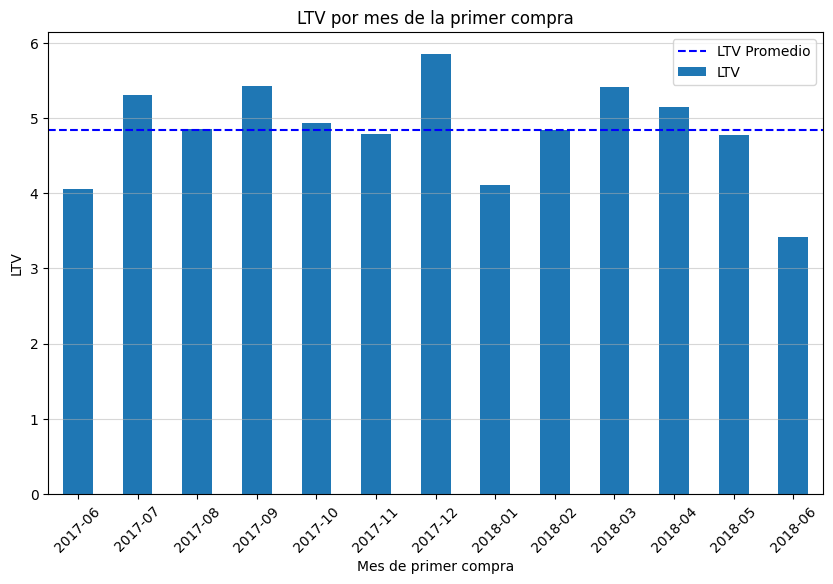

In [78]:
# Graficar el LTV
monthly_purchases.reset_index().plot(
    kind= 'bar',
    x= 'month',
    y= 'ltv',
    figsize= [10,6]
)
plt.axhline(
    monthly_purchases['ltv'].mean(),
    color='blue',
    linestyle= '--',
)
plt.legend(['LTV Promedio', 'LTV'])
plt.title('LTV por mes de la primer compra')
plt.xlabel('Mes de primer compra')
plt.ylabel('LTV')
plt.xticks(rotation=45)
plt.grid(axis= 'y', alpha= 0.5)

plt.show()

<b> CONCLUSIONES INTERMEDIAS

-	La mayoría de los usuarios (79%) hacen sus compras el mismo día de su registro; estos usuarios pertenecen al grupo 1.
-	Las fuentes de adquisición (publicidad) que mejor captan a este grupo de usuarios son la fuente 3 y 4.
-	La fuente de adquisición 5 logra captar más de 5000 compradores del grupo 1. Las fuentes 1 y 2, se quedan por debajo, pero logran captar mas de 2000. Finalmente ls fuentes 9 y 10 captan menos de 1000 compradores dentro de este grupo.
-	Para el resto de los grupos, es decir los que hacen su compra 1 día o más después de su registro, no se aprecia una diferencia muy significativa entre una fuente de adquisición y otra.
-	Las fuentes de adquisición 6 y 8 no captan clientes, y la fuente 7 solo tiene registrado a uno.
-	La cantidad promedio de compras semanales es 951 y el promedio mensual es de 3878
-	El ingreso promedio por semana es de 4755.8 y el promedio mensual es de 19389
-	Al analizar la cantidad de pedidos por semana, es posible ver como la cantidad de pedidos va teniendo picos una vez al mes; de igual forma los ingresos van teniendo picos una vez al mes.
-	Al hacer el mismo análisis de manera anual, es posible observar como los ingresos tienen un pico muy superior al promedio durante el mes de diciembre. Los meses con ingresos por arriba del promedio son Octubre, Noviembre, Diciembre, Febrero y Marzo
-	Al revisar el valor del ciclo de vida de los usuarios por el mes de la primer compra, la mayoría de los grupos están cerca del promedio, siendo el mas alto el mes de diciembre de 2017.


### 2.3. Marketing

In [79]:
# 1.¿Cuánto dinero se gastó? 
# Crear columna 'month' dentro del dataframe 'costs' para agrupar gastos por mes
costs['month'] = costs['dt'].dt.to_period('M')
monthly_costs = costs.groupby(['source_id', 'month']).agg({'costs':'sum'}).reset_index()

# Construir una tabla dinamica
monthly_costs_pivot = monthly_costs.pivot_table(
    index= 'month',
    columns= 'source_id',
    values= 'costs',
    aggfunc= 'mean'
)

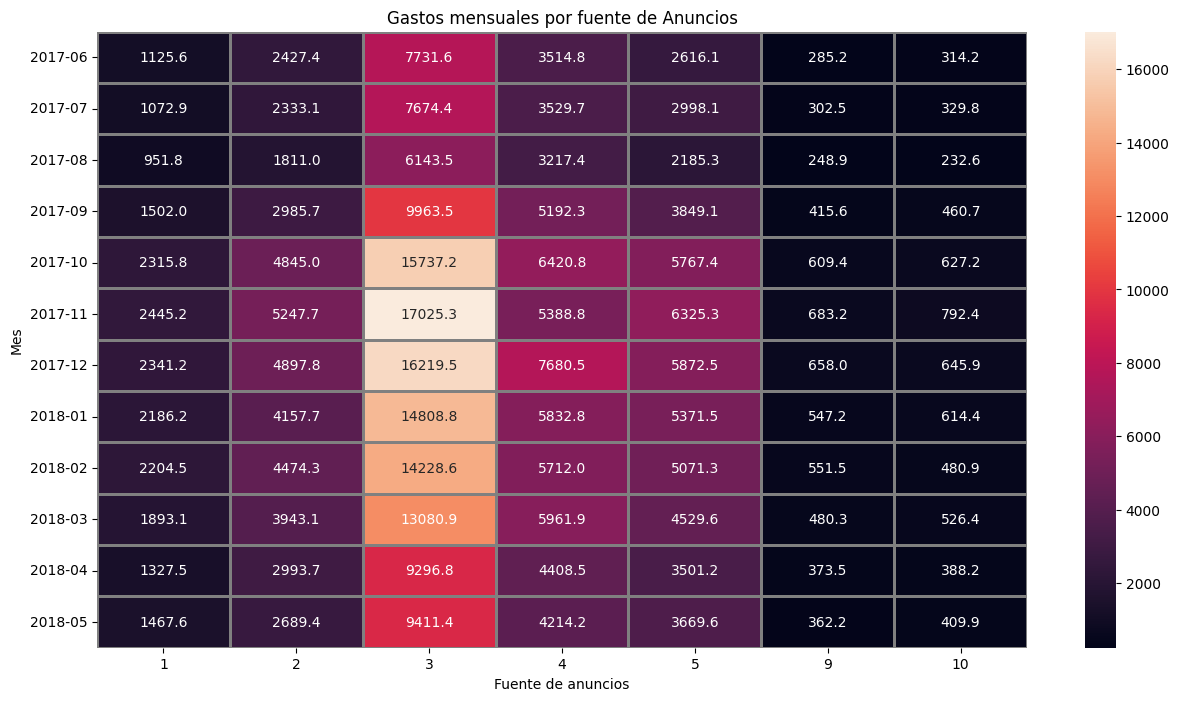

In [80]:
# Crear un mapa de calor
plt.figure(figsize=(15,8))
plt.title('Gastos mensuales por fuente de Anuncios')
sns.heatmap(
    monthly_costs_pivot,
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='gray',

)
plt.xlabel('Fuente de anuncios')
plt.ylabel('Mes')
plt.show()

In [83]:
# 2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
# Hacer un DataFrame con los costos totales por fuente
cost_by_source = costs.groupby(['month','source_id']).agg({'costs':'sum'}).reset_index()

# Filtrar 'buyers_visits' para el reporte de marketing
buyers_for_marketing = buyers_visits[['source_id', 'uid', 'day']]

# Crear la columna 'month' en el dataframe 'orders'
orders['month'] = orders['day'].dt.start_time.dt.to_period('M')

# Filtrar 'orders' para el reporte de marketing
orders_for_marketing = orders[['revenue', 'uid', 'day','month']]

# Unir los dataframes filtrados en 'uid' y 'day' coincidentes
buyers_and_orders = buyers_for_marketing.merge(orders_for_marketing, on=['uid', 'day'])
buyers_and_orders.head()

# Agrupar el nuevo DataFrame 'buyers_and_orders' para obtener datos por source_id por mes
orders_by_source = buyers_and_orders.groupby(['month','source_id']).agg({'uid':'nunique', 'revenue':'sum'}).reset_index()

# Crear un informe de marketing uniendo 'orders_by_source' con 'cost_by_source'
marketing_report = orders_by_source.merge(cost_by_source, on= ['month', 'source_id'], how= 'outer')

marketing_report.head()

,month,source_id,uid,revenue,costs
0,2017-06,1,277,2294.58,1125.61
1,2017-06,2,269,2403.05,2427.38
2,2017-06,3,612,2536.34,7731.65
3,2017-06,4,403,1863.02,3514.80
4,2017-06,5,410,2322.62,2616.12


In [84]:
# Calcular y crear las columnas con el LTV, CAC y ROMI de 'marketing_report'
marketing_report.columns = ['month', 'source_id', 'n_buyers', 'revenue', 'costs']
marketing_report['ltv'] = marketing_report['revenue'] / marketing_report['n_buyers']
marketing_report['cac'] = marketing_report['costs'] / marketing_report['n_buyers']
marketing_report['romi'] = marketing_report['ltv'] / marketing_report['cac']

marketing_report.head()

,month,source_id,n_buyers,revenue,costs,ltv,cac,romi
0,2017-06,1,277,2294.58,1125.61,8.283682,4.063574,2.038521
1,2017-06,2,269,2403.05,2427.38,8.933271,9.023717,0.989977
2,2017-06,3,612,2536.34,7731.65,4.144346,12.633415,0.328046
3,2017-06,4,403,1863.02,3514.80,4.622878,8.721588,0.530050
4,2017-06,5,410,2322.62,2616.12,5.664927,6.380780,0.887811


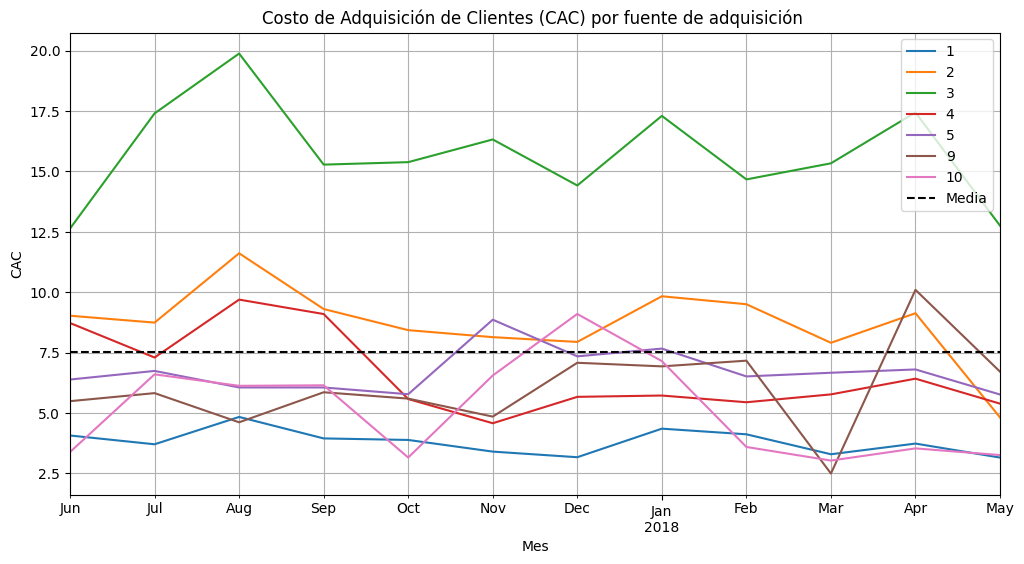

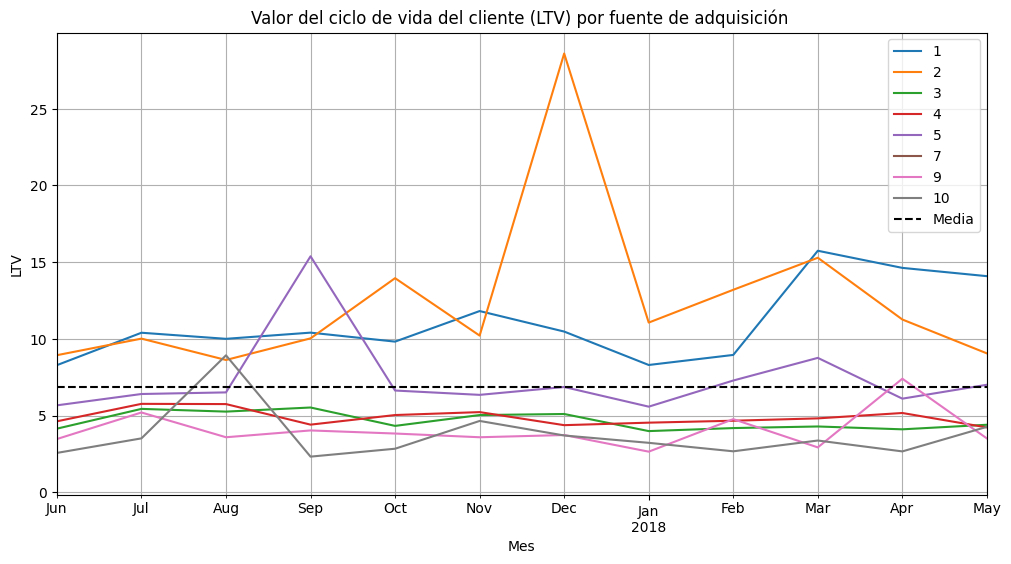

In [85]:
# Grafica para mostrar la variación del CAC entre diferentes source_id --------------------
cac_pivot = marketing_report.pivot_table(
    index= 'month',
    columns= 'source_id',
    values= 'cac',
    aggfunc='mean'
)

cac_pivot.plot(figsize= [12,6])
plt.axhline(
    marketing_report['cac'].mean(),
    color='black', 
    linestyle='--',
    label= 'Media')
plt.legend()
plt.grid(which= 'both')
plt.title('Costo de Adquisición de Clientes (CAC) por fuente de adquisición ')
plt.xlabel('Mes')
plt.ylabel('CAC')
plt.show()

# Grafica para mostrar la variación del LTV entre diferentes source_id --------------------
ltv_pivot = marketing_report.pivot_table(
    index= 'month',
    columns= 'source_id',
    values= 'ltv',
    aggfunc='mean'
)

ltv_pivot.plot(figsize= [12,6])
plt.axhline(
    marketing_report['ltv'].mean(),
    color='black', 
    linestyle='--',
    label= 'Media')
plt.legend()
plt.grid(which= 'both')
plt.title('Valor del ciclo de vida del cliente (LTV) por fuente de adquisición ')
plt.xlabel('Mes')
plt.ylabel('LTV')
plt.show()

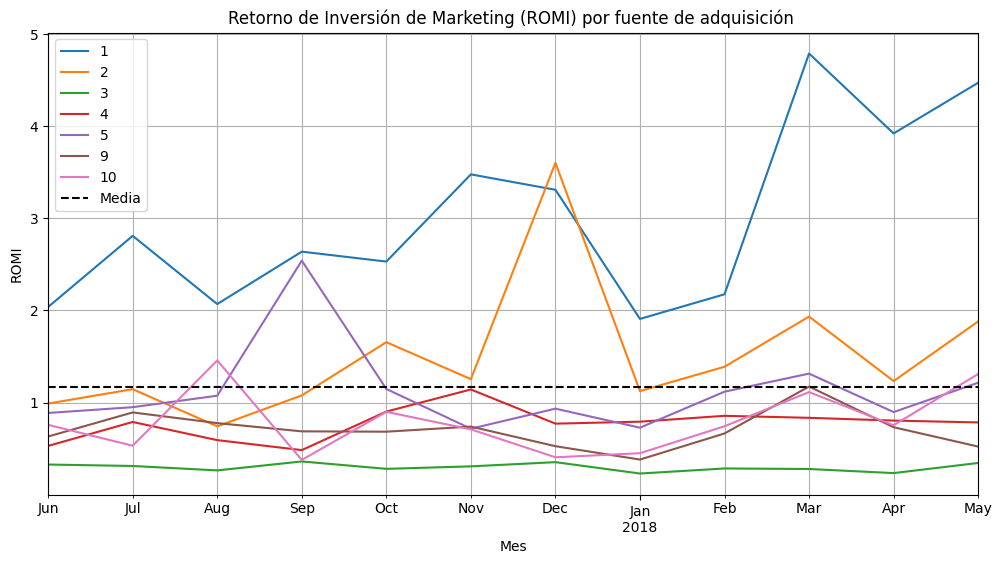

In [86]:
# 3. ¿Cuán rentables eran las inversiones? (ROMI)
# Grafica para mostrar la variación del ROMI entre diferentes source_id
romi_pivot = marketing_report.pivot_table(
    index= 'month',
    columns= 'source_id',
    values= 'romi',
    aggfunc='mean'
)

romi_pivot.plot(figsize= [12,6])
plt.axhline(
    marketing_report['romi'].mean(),
    color='black', 
    linestyle='--',
    label= 'Media')
plt.legend()
plt.grid(which= 'both')
plt.title('Retorno de Inversión de Marketing (ROMI) por fuente de adquisición ')
plt.xlabel('Mes')
plt.ylabel('ROMI')
plt.show()

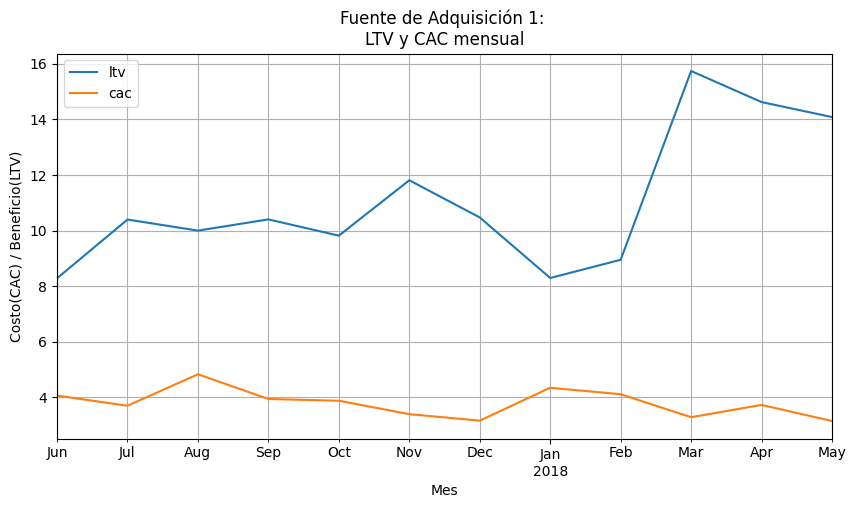

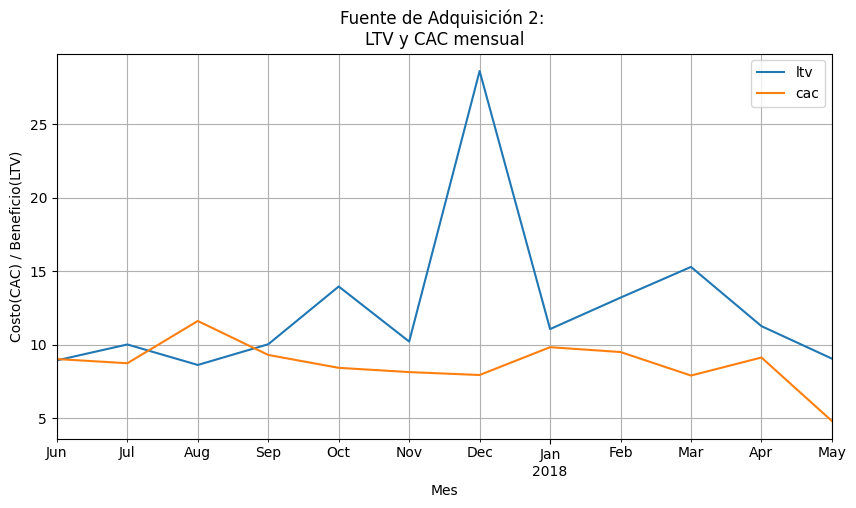

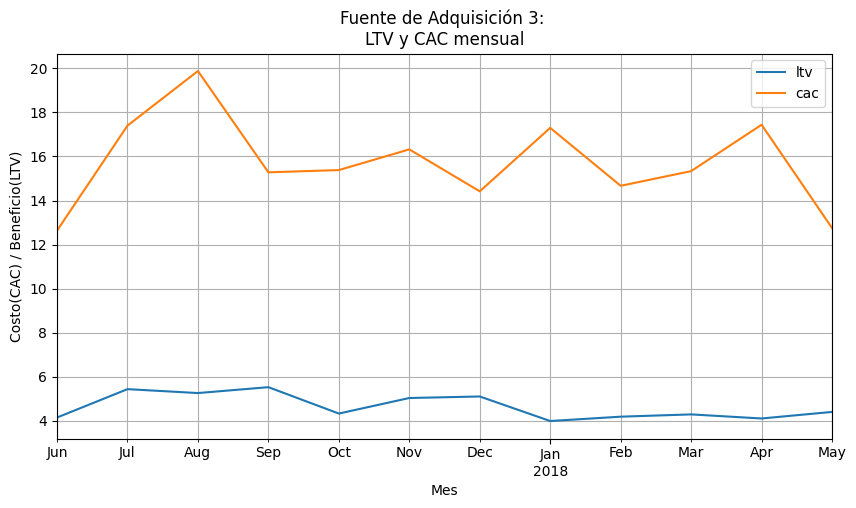

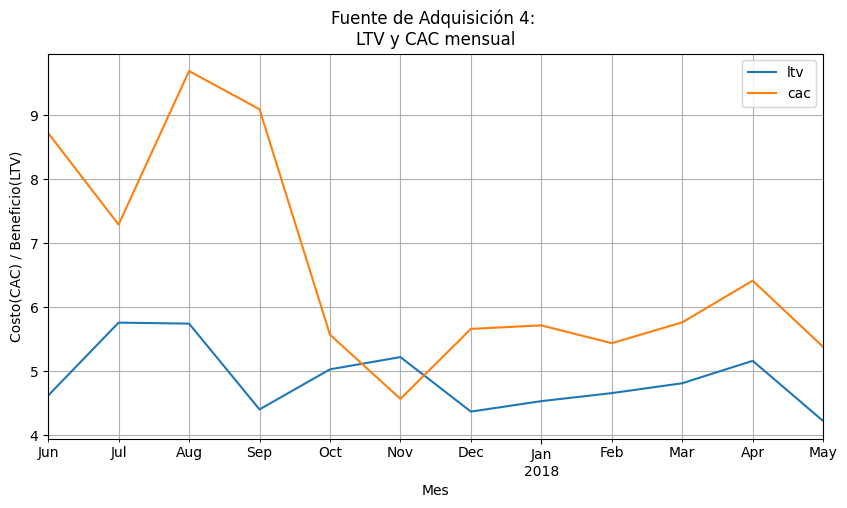

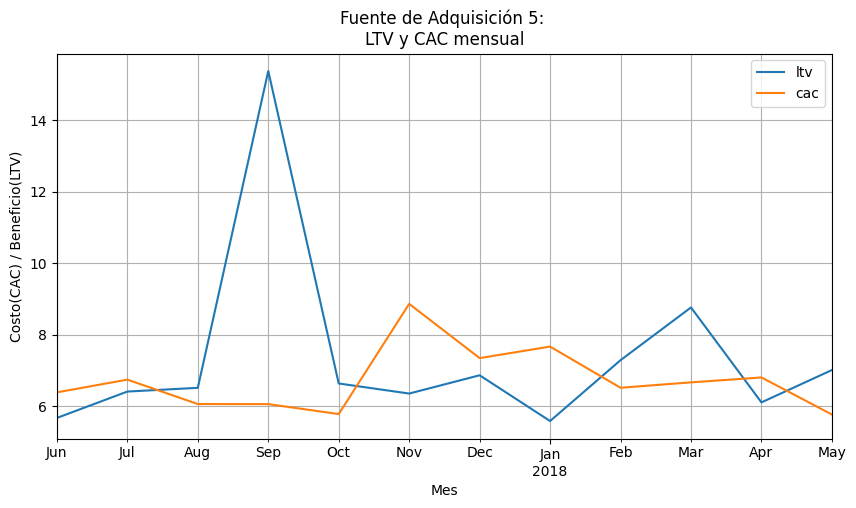

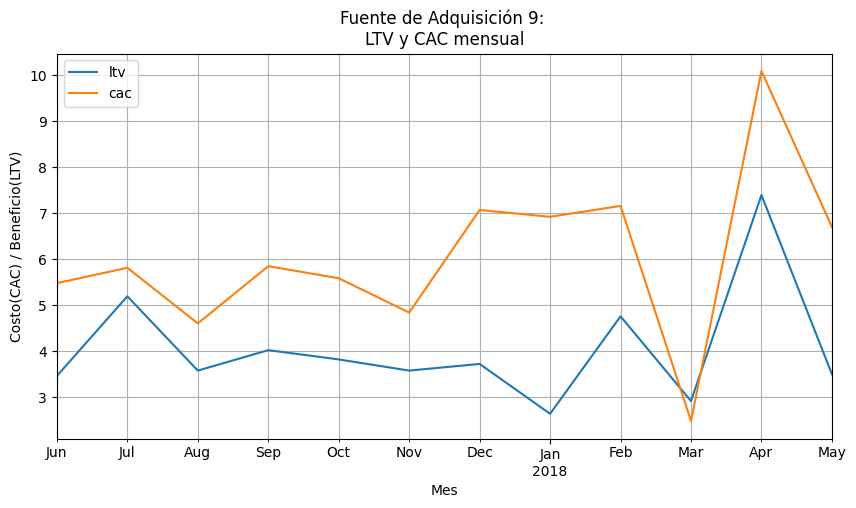

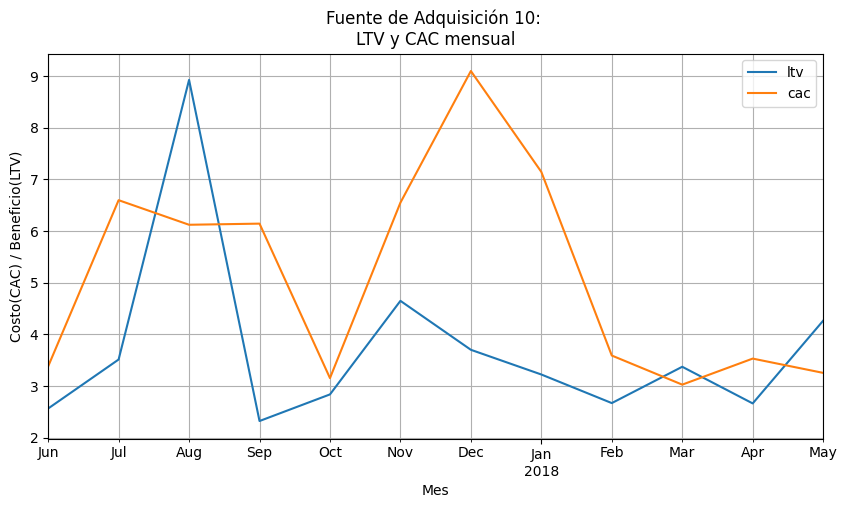

In [87]:
# Analisis por fuente de adquisición especifica

source_1_data = marketing_report[marketing_report['source_id'] == 1][['month','ltv', 'cac']]
source_1_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 1: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

source_2_data = marketing_report[marketing_report['source_id'] == 2][['month','ltv', 'cac']]
source_2_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 2: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

source_3_data = marketing_report[marketing_report['source_id'] == 3][['month','ltv', 'cac']]
source_3_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 3: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

source_4_data = marketing_report[marketing_report['source_id'] == 4][['month','ltv', 'cac']]
source_4_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 4: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

source_5_data = marketing_report[marketing_report['source_id'] == 5][['month','ltv', 'cac']]
source_5_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 5: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

source_9_data = marketing_report[marketing_report['source_id'] == 9][['month','ltv', 'cac']]
source_9_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 9: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

source_10_data = marketing_report[marketing_report['source_id'] == 10][['month','ltv', 'cac']]
source_10_data.plot(x='month', figsize= [10,5])
plt.title('Fuente de Adquisición 10: \nLTV y CAC mensual')
plt.xlabel('Mes')
plt.ylabel('Costo(CAC) / Beneficio(LTV)')
plt.grid(which='both')

plt.show()

<b> CONCLUSIONES INTERMEDIAS

-	Las fuentes de adquisición (anuncios) que más gastan son la 3 y 4.
-	Todas las fuentes de adquisición presentan sus mayores gastos entre los meses de Octubre, Noviembre y Diciembre.
-	El mayor costo de adquisición de clientes lo tienen las fuentes de adquisición 3 y 2, estando por encima de la media todo el año. 
-	Las fuentes de adquisición 4, 5, 9 y 10  tienen un CAC por encima de la media en algunos meses.
-	Las fuente con menor CAC fue la 1.
-	Las fuente con el mejor Retorno de Inversión de Marketing (ROMI) fue la 1. En segundo lugar la fuente 2, tuvo un ROMI mayor a 1 la mayor parte del año.
-	La fuente 5 tuvo un buen ROMI en septiembre y se mantuvo cerca del valor 1 la mayor parte del año.
-	El resto de las fuentes estuvieron por debajo del valor 1 la mayor parte del año, siendo la fuente 3 la que peor ROMI tuvo.


## 3. Conclusiones Finales

-	Tomando en cuenta todo lo anterior, la fuente de adquisición más recomendable es la 1, ya que atrae una buena cantidad de clientes, los cuales generan los mejores ingresos y su CAC es de los más bajos de entre el resto de las fuentes.
-	La fuente 3, tiene serios problemas porque, a pesar de que mostró atraer una gran cantidad de compradores, genera muchos gastos que no compensan los ingresos que genera. La recomendación es no seguir invirtiendo en esa fuente. 
-	La fuente 4 también presenta muchos problemas, la mayor parte del año el CAC es mas alto que el LTV, solo en noviembre el LTV tuvo un despunte. La recomendación es no seguir invirtiendo en esa fuente.
-	La fuente 2, casi siempre tiene un mejor LTV, que su CAC pero durante los meses de menores ingresos que son Junio, Julio, Agosto y Septiembre se ve en problemas. Lo mejor sería concentrase en mejorar la estrategia de marketing de esta fuente durante esos meses o incluso retirarla durante ese periodo donde no le esta yendo bien. Donde si tiene mucho potencial es para las ventas de Diciembre. La recomendación es aprovecharla al final y principio del año.
-	La fuente 5 tiene potencial de mejora, ya que sus CAC no esta muy por debajo del LTV y tiene despuntes buenos en el mes de Septiembre y Marzo.
-	Las fuentes 9 y 10, en lo general parecen ser mas costosas que el beneficio que otorgan. Sin embargo la fuente 10 mostró un buen resultado en el mes de Agosto. La recomendación es estudiar que sucedió con esta fuente ese mes para ver si es algo que se puede replicar el resto del año, de lo contrario la recomendación es dejar de invertir en ella.
-	Otro punto a considerar es que las ordenes se ven influenciadas por que semana del mes es, siendo alrededor de la tercer semana el momento del mes con mejores resultados en cantidad de ordenes e ingresos. La recomendación es generar estrategias de marketing concentradas en ese periodo del mes.
-	También hay que considerar el ciclo anual, que mostró que alrededor de los meses de noviembre y diciembre es cuando las ingresos se recaudan.
